# Práctica 05: Análisis Exploratorio de Datos con Expedientes Clínicos

**Nombre del Estudiante:** Carlos Daniel Garcia Pluma  
**Matrícula:** 230187  
**Grado y Grupo:** 9°A IDGS

**Programa de Estudios:** Ingeniería en Desarrollo y Gestión de Software  
**Asignatura:** Extracción de Conocimiento en Base de Datos  
**Docente:** M.T.I. Marco A. Ramírez Hernández  
**Periodo:** Mayo - Agosto 2026

En esta práctica se analizará el dataset de expedientes clínicos de Puebla para identificar patrones relevantes en variables como edad, presión arterial, IMC, triage, sexo biológico y estado nutricional.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

ruta = 'expedientes_clinicos_puebla_1.csv'
df = pd.read_csv(ruta)
df.head()

,ID_Expediente,CURP,RFC,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo_Biologico,Estado,...,Estatura_cm,Peso_kg,IMC,Estado_Nutricional,CIE10_Diagnostico,Diagnostico_Principal,Sintoma_Principal,Tratamiento_Farmacologico,Medico_Tratante_Cedula,Fecha_Hora_Apertura_Expediente
0,EXP-2026-00001,MAGM931226HPLRRG05,MAGM931226I10,Miguel,Martínez,García,1993-12-26,32,MASCULINO,Puebla,...,172.8,71.5,23.9,Normal,I10,Hipertensión Arterial Esencial,Cefalea holocraneal pulsátil y acúfenos,Losartán 50mg cada 12 hrs VO + Amlodipino 5mg ...,9027271,2026-03-03 06:57:04
1,EXP-2026-00002,RELF690520HPLYÓR04,RELF690520E63,Francisco,Reyes,López,1969-05-20,57,MASCULINO,Puebla,...,169.5,89.5,31.2,Obesidad,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,3502118,2026-01-30 14:03:04
2,EXP-2026-00003,VUSJ390226MPLÁÁN01,VUSJ390226A43,Juana,Vázquez,Sánchez,1939-02-26,87,FEMENINO,Puebla,...,153.7,74.3,31.5,Obesidad,N18.4,Insuficiencia Renal Crónica Estadío 4,"Edema de miembros inferiores, astenia y oliguria",Eritropoyetina 4000 UI SC semanal + Carbonato ...,5101034,2026-03-31 05:12:04
3,EXP-2026-00004,RAMV850725MPLMRR06,RAMV850725T43,Verónica,Ramírez,Martínez,1985-07-25,41,FEMENINO,Puebla,...,157.0,62.0,25.2,Sobrepeso,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,8578419,2026-02-04 21:11:04
4,EXP-2026-00005,PERM700815MPLÉYR07,PERM700815178,Margarita,Pérez,Reyes,1970-08-15,55,FEMENINO,Puebla,...,145.3,69.0,32.7,Obesidad,E11,Diabetes Mellitus Tipo 2,"Poliuria, polidipsia y fatiga crónica",Metformina 850mg cada 12 hrs VO + Empagliflozi...,9245419,2026-06-06 03:22:04


## 2. Ejemplos visibles del dataset

A continuación se muestran por separado:
- los primeros 10 registros,
- los últimos 10 registros,
- y el conteo de una variable categórica, en este caso Sexo_Biologico.

## 1. Carga del dataset

Se importa el archivo CSV y se revisa la estructura general del dataset.

In [21]:
# Primeros 10 registros
df.head(10)

,ID_Expediente,CURP,RFC,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo_Biologico,Estado,...,Estatura_cm,Peso_kg,IMC,Estado_Nutricional,CIE10_Diagnostico,Diagnostico_Principal,Sintoma_Principal,Tratamiento_Farmacologico,Medico_Tratante_Cedula,Fecha_Hora_Apertura_Expediente
0,EXP-2026-00001,MAGM931226HPLRRG05,MAGM931226I10,Miguel,Martínez,García,1993-12-26,32,MASCULINO,Puebla,...,172.8,71.5,23.9,Normal,I10,Hipertensión Arterial Esencial,Cefalea holocraneal pulsátil y acúfenos,Losartán 50mg cada 12 hrs VO + Amlodipino 5mg ...,9027271,2026-03-03 06:57:04
1,EXP-2026-00002,RELF690520HPLYÓR04,RELF690520E63,Francisco,Reyes,López,1969-05-20,57,MASCULINO,Puebla,...,169.5,89.5,31.2,Obesidad,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,3502118,2026-01-30 14:03:04
2,EXP-2026-00003,VUSJ390226MPLÁÁN01,VUSJ390226A43,Juana,Vázquez,Sánchez,1939-02-26,87,FEMENINO,Puebla,...,153.7,74.3,31.5,Obesidad,N18.4,Insuficiencia Renal Crónica Estadío 4,"Edema de miembros inferiores, astenia y oliguria",Eritropoyetina 4000 UI SC semanal + Carbonato ...,5101034,2026-03-31 05:12:04
3,EXP-2026-00004,RAMV850725MPLMRR06,RAMV850725T43,Verónica,Ramírez,Martínez,1985-07-25,41,FEMENINO,Puebla,...,157.0,62.0,25.2,Sobrepeso,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,8578419,2026-02-04 21:11:04
4,EXP-2026-00005,PERM700815MPLÉYR07,PERM700815178,Margarita,Pérez,Reyes,1970-08-15,55,FEMENINO,Puebla,...,145.3,69.0,32.7,Obesidad,E11,Diabetes Mellitus Tipo 2,"Poliuria, polidipsia y fatiga crónica",Metformina 850mg cada 12 hrs VO + Empagliflozi...,9245419,2026-06-06 03:22:04
5,EXP-2026-00006,ROGL520807MPLDNT03,ROGL520807G55,Leticia Guadalupe,Rodríguez,González,1952-08-07,73,FEMENINO,Puebla,...,172.1,96.3,32.5,Obesidad,N18.4,Insuficiencia Renal Crónica Estadío 4,"Edema de miembros inferiores, astenia y oliguria",Eritropoyetina 4000 UI SC semanal + Carbonato ...,5639715,2026-05-27 21:15:04
6,EXP-2026-00007,VUMR800117HPLÁRC01,VUMR800117G46,Ricardo Carlos,Vázquez,Martínez,1980-01-17,46,MASCULINO,Puebla,...,174.6,75.9,24.9,Normal,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,9674971,2026-01-18 13:58:04
7,EXP-2026-00008,CUGS090629MPLRÓF01,CUGS090629966,Sofia,Cruz,Gómez,2009-06-29,17,FEMENINO,Puebla,...,147.7,62.4,28.6,Sobrepeso,E11,Diabetes Mellitus Tipo 2,"Poliuria, polidipsia y fatiga crónica",Metformina 850mg cada 12 hrs VO + Empagliflozi...,9118668,2026-06-25 07:28:04
8,EXP-2026-00009,GEFR660526MPLÓLS05,GEFR660526D87,Rosa,Gómez,Flores,1966-05-26,60,FEMENINO,Puebla,...,161.1,63.1,24.3,Normal,J45.9,Asma Bronquial Exacerbada,Disnea de medianos esfuerzos y sibilancias esp...,Salbutamol 2 disparos cada 4 hrs en aerosol + ...,5997799,2026-03-22 12:20:04
9,EXP-2026-00010,HEMM810817HPLRRN03,HEMM810817G47,Manuel,Hernández,Martínez,1981-08-17,44,MASCULINO,Puebla,...,170.5,67.0,23.0,Normal,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,4111222,2026-04-11 13:50:04


## 2. Resumen estadístico básico

Se obtienen medidas descriptivas de las variables numéricas más importantes del dataset.

In [18]:
# Últimos 10 registros
df.tail(10)

,ID_Expediente,CURP,RFC,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo_Biologico,Estado,...,Estatura_cm,Peso_kg,IMC,Estado_Nutricional,CIE10_Diagnostico,Diagnostico_Principal,Sintoma_Principal,Tratamiento_Farmacologico,Medico_Tratante_Cedula,Fecha_Hora_Apertura_Expediente
5490,EXP-2026-05491,RELR840701MPLYÓS02,RELR840701C12,Rosa Margarita,Reyes,López,1984-07-01,42,FEMENINO,Puebla,...,152.8,68.3,29.3,Sobrepeso,I10,Hipertensión Arterial Esencial,Cefalea holocraneal pulsátil y acúfenos,Losartán 50mg cada 12 hrs VO + Amlodipino 5mg ...,7577683,2026-05-31 04:42:04
5491,EXP-2026-05492,REHA850324MPLYRN09,REHA850324E22,Ana María,Reyes,Hernández,1985-03-24,41,FEMENINO,Puebla,...,152.5,82.8,35.6,Obesidad,E11,Diabetes Mellitus Tipo 2,"Poliuria, polidipsia y fatiga crónica",Metformina 850mg cada 12 hrs VO + Empagliflozi...,3999527,2026-02-09 17:59:04
5492,EXP-2026-05493,FOMS070223MPLLRF01,FOMS070223R21,Sofia,Flores,Morales,2007-02-23,19,FEMENINO,Puebla,...,147.0,62.1,28.7,Sobrepeso,A09,Gastroenteritis Infecciosa,"Evacuaciones líquidas recurrentes, dolor cólic...",Ciprofloxacino 500mg cada 12 hrs VO por 5 días...,4469799,2026-01-25 00:36:04
5493,EXP-2026-05494,SEGJ570926HPLÁNR08,SEGJ570926088,Jorge Juan,Sánchez,González,1957-09-26,68,MASCULINO,Puebla,...,161.3,69.3,26.6,Sobrepeso,A09,Gastroenteritis Infecciosa,"Evacuaciones líquidas recurrentes, dolor cólic...",Ciprofloxacino 500mg cada 12 hrs VO por 5 días...,9991259,2026-05-10 13:59:04
5494,EXP-2026-05495,VULA781217MPLÁÓN07,VULA781217U43,Ana,Vázquez,López,1978-12-17,47,FEMENINO,Puebla,...,159.9,71.5,28.0,Sobrepeso,J00,Rinofaringitis Aguda,"Rinorrea hialina, odinofagia intensa y estornudos",Paracetamol 500mg cada 8 hrs VO + Loratadina 1...,9518459,2026-07-02 12:58:04
5495,EXP-2026-05496,GARM960704MPLRDR08,GARM960704E80,María Elena,García,Rodríguez,1996-07-04,30,FEMENINO,Puebla,...,147.4,56.7,26.1,Sobrepeso,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,8797485,2026-05-13 19:42:04
5496,EXP-2026-05497,RACJ660317HPLMSN04,RACJ660317L98,Juan,Ramírez,Castro,1966-03-17,60,MASCULINO,Puebla,...,159.3,78.1,30.8,Obesidad,N39.0,Infección de Vías Urinarias,"Disuria, tenesmo vesical y dolor suprapúbico",Nitrofurantoína 100mg cada 6 hrs VO por 7 días,7432440,2026-02-21 07:15:04
5497,EXP-2026-05498,TOGJ460924HPLRNS03,TOGJ460924U51,Jesús Alejandro,Torres,González,1946-09-24,79,MASCULINO,Puebla,...,165.3,69.5,25.4,Sobrepeso,I10,Hipertensión Arterial Esencial,Cefalea holocraneal pulsátil y acúfenos,Losartán 50mg cada 12 hrs VO + Amlodipino 5mg ...,6376493,2026-02-27 02:28:04
5498,EXP-2026-05499,FOMA821229MPLLRN02,FOMA821229198,Ana,Flores,Martínez,1982-12-29,43,FEMENINO,Puebla,...,143.0,39.1,19.1,Normal,N18.4,Insuficiencia Renal Crónica Estadío 4,"Edema de miembros inferiores, astenia y oliguria",Eritropoyetina 4000 UI SC semanal + Carbonato ...,9919398,2026-05-07 11:06:04
5499,EXP-2026-05500,HEMR030129HPLRRC02,HEMR030129T12,Ricardo,Hernández,Martínez,2003-01-29,23,MASCULINO,Puebla,...,161.1,73.9,28.5,Sobrepeso,A09,Gastroenteritis Infecciosa,"Evacuaciones líquidas recurrentes, dolor cólic...",Ciprofloxacino 500mg cada 12 hrs VO por 5 días...,3053182,2026-01-21 15:11:04


# Conteo de la variable categórica Sexo_Biologico
df['Sexo_Biologico'].value_counts()

In [ ]:
df.info()
df.isna().sum()

## 4. Limpieza básica de datos

El dataset no presenta valores faltantes, por lo que se conserva sin modificaciones adicionales.

In [ ]:
# Se conserva el dataset tal como está porque no hay valores faltantes
df.shape

## 5. Análisis descriptivo por variables

Se exploran las variables categóricas más relevantes del dataset para identificar tendencias.

In [ ]:
# Se muestran de nuevo los datos para confirmar la calidad del dataset
df.info()
df.isna().sum()

## 4. Limpieza básica de datos

Se identifican los valores faltantes y se preparan los datos para el análisis exploratorio.

## 6. Visualización de variables numéricas

Se analizan variables cuantitativas para identificar distribuciones y relaciones importantes.

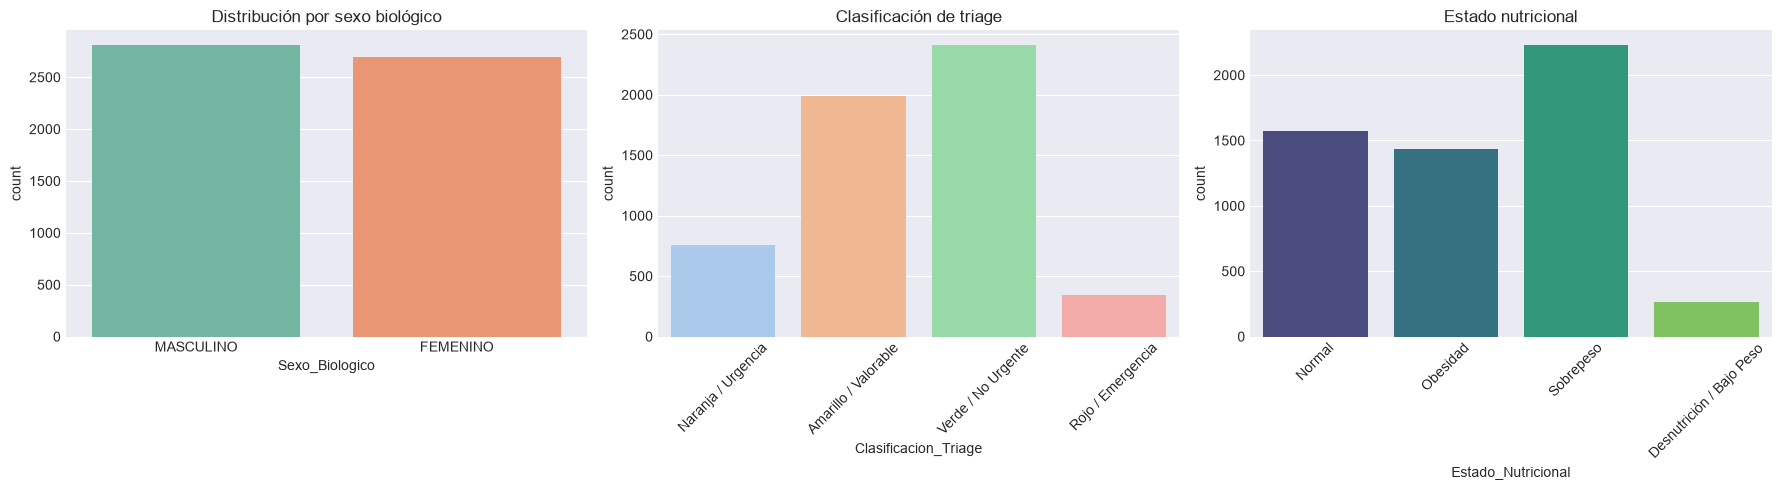

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Sexo_Biologico', hue='Sexo_Biologico', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución por sexo biológico')

sns.countplot(data=df, x='Clasificacion_Triage', hue='Clasificacion_Triage', legend=False, ax=axes[1], palette='pastel')
axes[1].set_title('Clasificación de triage')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Estado_Nutricional', hue='Estado_Nutricional', legend=False, ax=axes[2], palette='viridis')
axes[2].set_title('Estado nutricional')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Mapas de calor y distribución geográfica

Se utilizan mapas de calor para identificar relaciones entre variables y una vista geográfica simple de los registros dentro de Puebla.

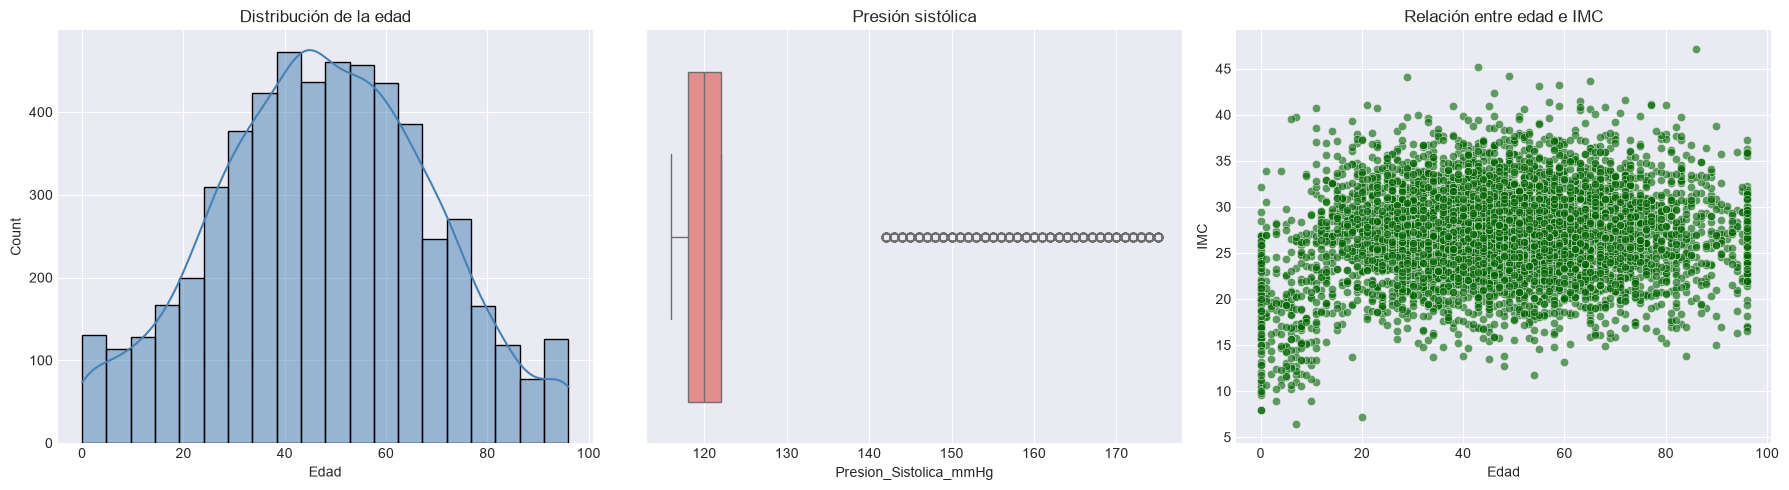

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Edad'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de la edad')

sns.boxplot(x=df['Presion_Sistolica_mmHg'], ax=axes[1], color='lightcoral')
axes[1].set_title('Presión sistólica')

sns.scatterplot(data=df, x='Edad', y='IMC', alpha=0.6, ax=axes[2], color='darkgreen')
axes[2].set_title('Relación entre edad e IMC')

plt.tight_layout()
plt.show()

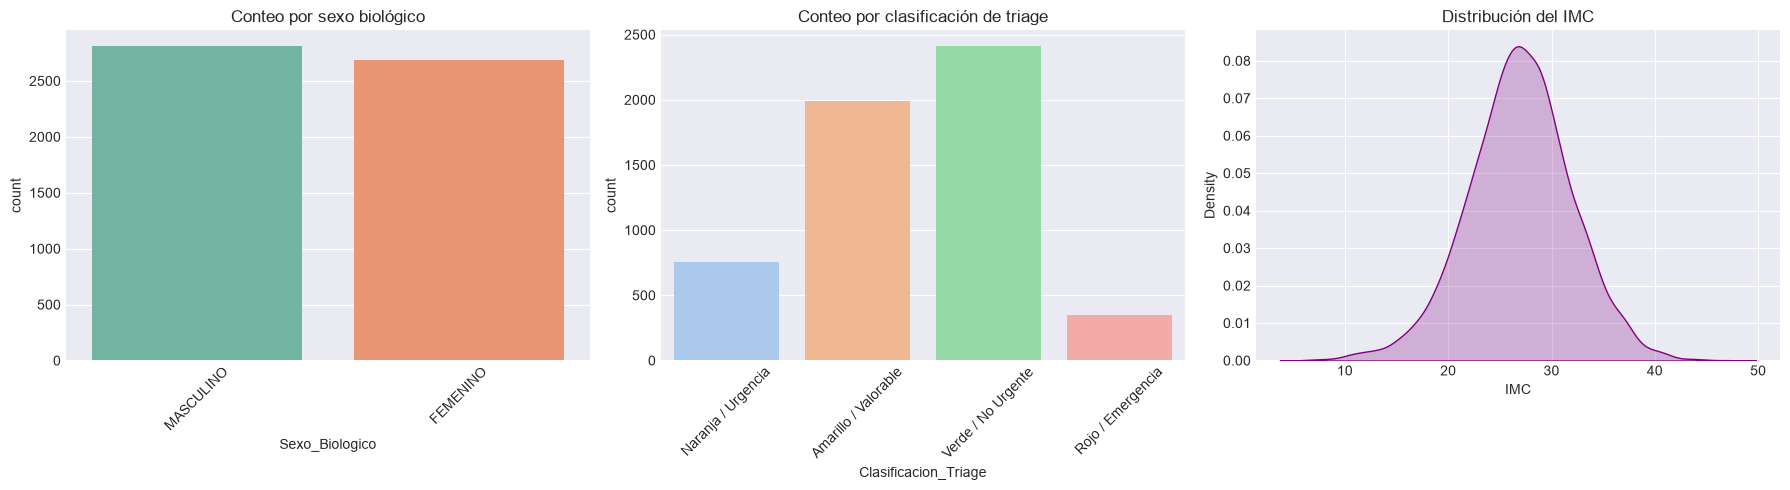

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Sexo_Biologico', hue='Sexo_Biologico', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Conteo por sexo biológico')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Clasificacion_Triage', hue='Clasificacion_Triage', legend=False, palette='pastel', ax=axes[1])
axes[1].set_title('Conteo por clasificación de triage')
axes[1].tick_params(axis='x', rotation=45)

sns.kdeplot(data=df, x='IMC', fill=True, color='purple', ax=axes[2])
axes[2].set_title('Distribución del IMC')

plt.tight_layout()
plt.show()

## 7. Mapas de calor

Se crean mapas de calor para identificar relaciones entre variables numéricas, comparaciones entre categorías y la distribución geográfica de los registros dentro del estado de Puebla.

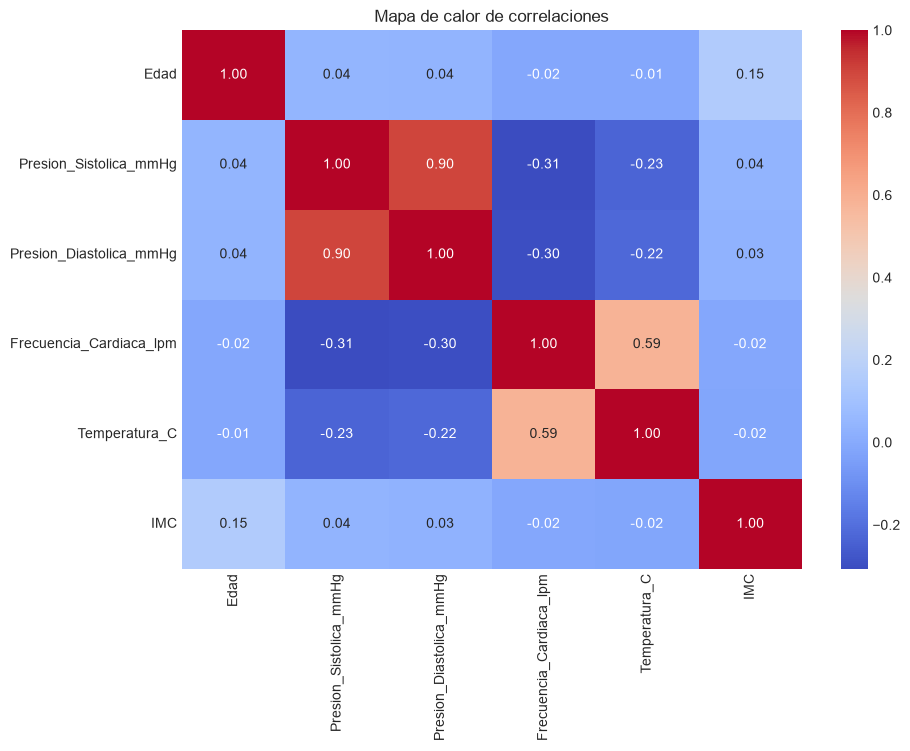

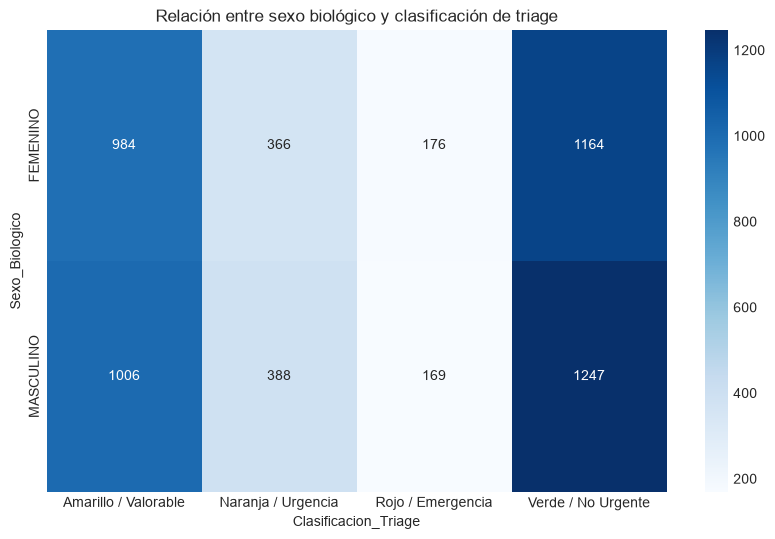

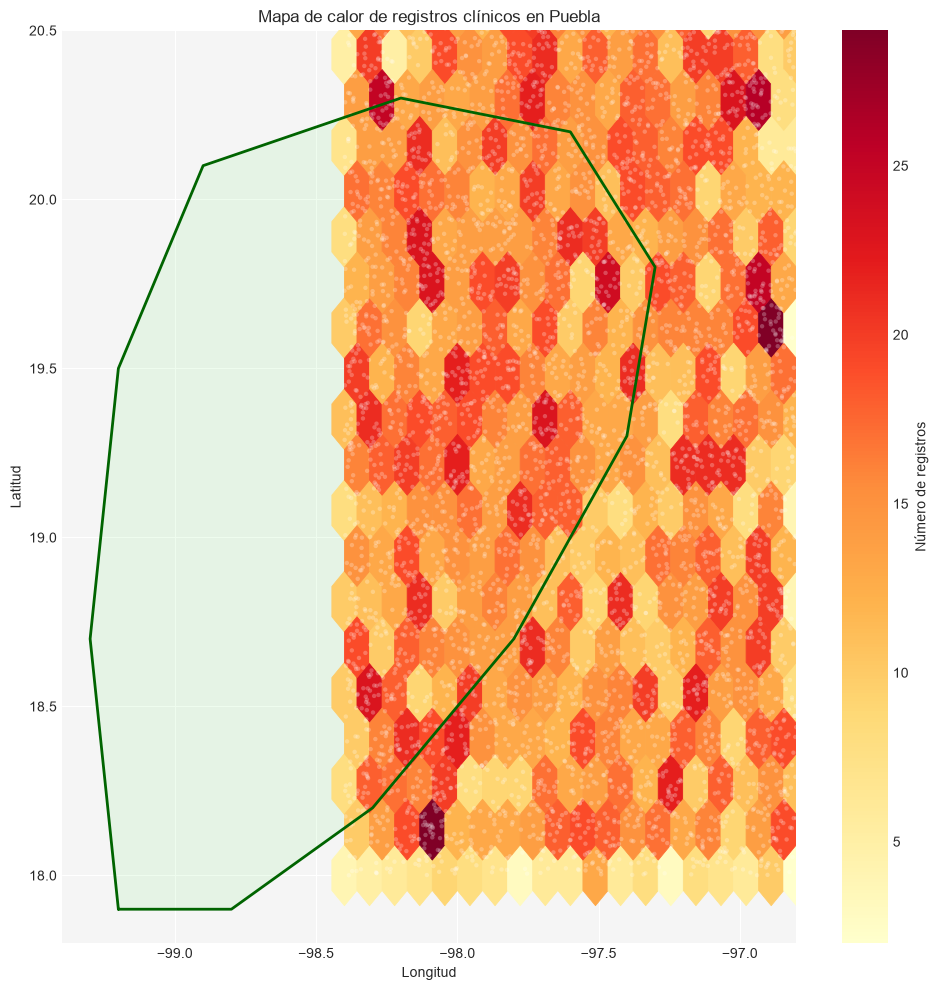

In [13]:
variables_num = df[['Edad', 'Presion_Sistolica_mmHg', 'Presion_Diastolica_mmHg', 'Frecuencia_Cardiaca_lpm', 'Temperatura_C', 'IMC']]
matriz_corr = variables_num.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones')
plt.show()

conteo_sexo_triage = pd.crosstab(df['Sexo_Biologico'], df['Clasificacion_Triage'])

plt.figure(figsize=(10, 6))
sns.heatmap(conteo_sexo_triage, annot=True, cmap='Blues', fmt='d')
plt.title('Relación entre sexo biológico y clasificación de triage')
plt.show()

# Mapa de calor geográfico estilo mapa para Puebla
plt.figure(figsize=(10, 10))
ax = plt.gca()

# Límites aproximados del estado de Puebla
ax.set_xlim(-99.4, -96.8)
ax.set_ylim(17.8, 20.5)

# Contorno aproximado del estado de Puebla
puebla_outline = np.array([
    [-99.2, 17.9],
    [-98.8, 17.9],
    [-98.3, 18.2],
    [-97.8, 18.7],
    [-97.4, 19.3],
    [-97.3, 19.8],
    [-97.6, 20.2],
    [-98.2, 20.3],
    [-98.9, 20.1],
    [-99.2, 19.5],
    [-99.3, 18.7],
    [-99.2, 17.9],
])
ax.plot(puebla_outline[:, 0], puebla_outline[:, 1], color='darkgreen', linewidth=2)
ax.fill(puebla_outline[:, 0], puebla_outline[:, 1], color='lightgreen', alpha=0.15)

# Densidad espacial de los registros clínicos
hb = ax.hexbin(df['Longitud'], df['Latitud'], gridsize=18, cmap='YlOrRd', mincnt=1, linewidths=0.6)
plt.colorbar(hb, ax=ax, label='Número de registros')

# Puntos de los registros sobre el mapa
ax.scatter(df['Longitud'], df['Latitud'], c='white', s=10, alpha=0.25, edgecolors='none')

ax.set_title('Mapa de calor de registros clínicos en Puebla')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_facecolor('#f5f5f5')

plt.tight_layout()
plt.show()

## 8. Conclusiones

A partir del análisis del dataset se observan tendencias relevantes en salud, nutrición y distribución de los registros, lo que permite comprender mejor la información clínica disponible.

## 9. Actividad de cierre

Analiza otra variable del dataset y compara tus observaciones con las encontradas en esta práctica.